In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('course.csv')
print(df.head())


   Age             Education   Background     Interest    SkillLevel  \
0   21  Working Professional      Science      Finance      Advanced   
1   35           High School         Arts     Business  Intermediate   
2   40           High School         Arts    Marketing      Beginner   
3   17         Undergraduate     Commerce      Finance  Intermediate   
4   24           High School  Engineering  Programming      Advanced   

   LearningStyle StudyTime      CareerGoal  Budget    Duration  \
0        Reading       20+  Higher Studies    Free   6+ months   
1  Project Based     10-20  Start Business  Medium   6+ months   
2          Video       20+         Get Job    Free   6+ months   
3          Video        <5   Skill Upgrade    Free  3-6 months   
4      Practical      5-10   Skill Upgrade    Free  3-6 months   

      RecommendedCourse  
0  Finance & Investment  
1          Data Science  
2    Python Programming  
3        Graphic Design  
4      Machine Learning  


In [3]:
df.shape

(500, 11)

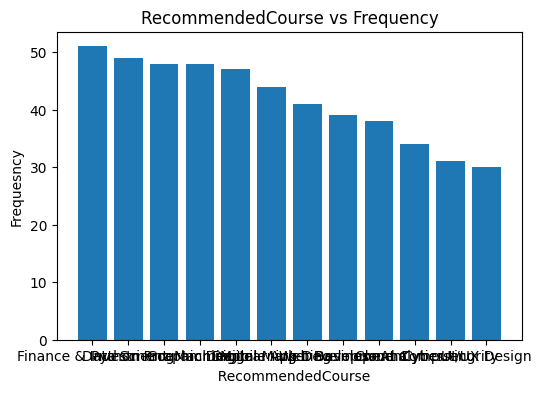

In [4]:
plt.figure(figsize=(6,4))
plt.bar(x=df['RecommendedCourse'].unique(), height=df['RecommendedCourse'].value_counts())
plt.xlabel("  RecommendedCourse")
plt.ylabel("Frequesncy")
plt.title("RecommendedCourse vs Frequency")
plt.savefig('plot.png')
plt.show()

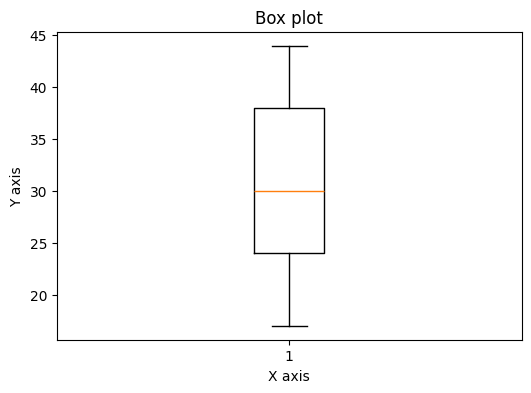

In [5]:
plt.figure(figsize=(6,4))
plt.boxplot(df.drop(columns=['RecommendedCourse']).select_dtypes(include=[np.number]));
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.title("Box plot")
plt.savefig("boxplot.svg",format="svg")
plt.show()
#here it is showing boxlot only of numeric columns and it is dropping the non numeric columns from the dataset

In [6]:
#split into x and y
X= df.drop(columns=['RecommendedCourse'])
y=df["RecommendedCourse"]
#to dind the dimenionwe use 
# print(X.shape)
#X.shape

In [7]:
#split into training and testing set 
from sklearn.model_selection import train_test_split
X= df.drop(columns=['RecommendedCourse'])
y=df['RecommendedCourse']
print(X.shape)
print(y.shape)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=123)

print(f'length of X_train and y_train ={X_train.shape}{y_train.shape}')
print(f"length of X_test and y_test={X_test.shape}{y_test.shape}")


(500, 10)
(500,)
length of X_train and y_train =(400, 10)(400,)
length of X_test and y_test=(100, 10)(100,)


In [8]:
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score , classification_report 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

df = pd.read_csv('course.csv')

X = df.drop('RecommendedCourse', axis=1)
y = df['RecommendedCourse']

# 🔥 Encode features
X = pd.get_dummies(X)

# 🔥 Encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.09


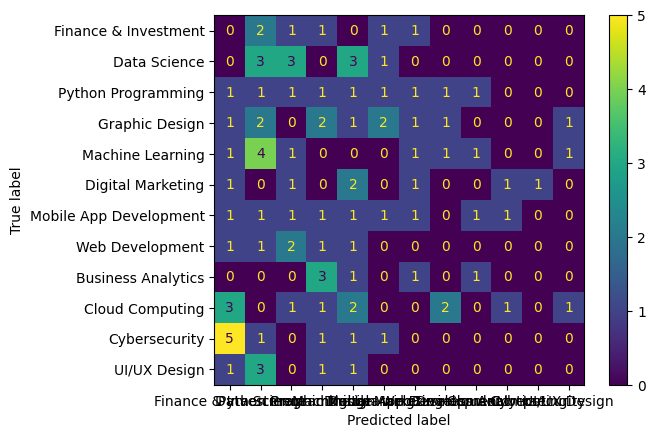

In [10]:
cm =confusion_matrix(y_test,y_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=df['RecommendedCourse'].unique())

cm_plot.plot()
plt.savefig("cm.png")
plt.show()

In [11]:
X_test

,Age,Education_Graduate,Education_High School,Education_Undergraduate,Education_Working Professional,Background_Arts,Background_Commerce,Background_Engineering,Background_IT,Background_Management,...,CareerGoal_Higher Studies,CareerGoal_Skill Upgrade,CareerGoal_Start Business,Budget_Free,Budget_Low,Budget_Medium,Budget_Premium,Duration_1-3 months,Duration_3-6 months,Duration_6+ months
129,28,False,False,False,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
461,30,False,False,False,True,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
120,18,False,True,False,False,False,False,False,True,False,...,True,False,False,False,True,False,False,True,False,False
352,36,True,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
323,32,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,23,False,False,False,True,False,False,False,True,False,...,False,True,False,False,False,False,True,True,False,False
231,43,True,False,False,False,False,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
249,41,False,False,True,False,False,True,False,False,False,...,False,False,True,True,False,False,False,True,False,False
193,18,True,False,False,False,False,False,False,True,False,...,False,True,False,False,False,False,True,True,False,False


In [12]:
y_test

array([ 6,  4,  7,  9,  5,  1,  8,  7,  0,  6,  3, 10,  0,  4,  1,  8,  9,
        1,  0, 11,  2,  8,  8, 11,  9, 10,  9,  5,  3,  2,  1,  3, 11, 10,
        1, 11,  9,  6,  5,  1,  5,  6,  2,  0,  9, 10,  3,  1,  1,  8,  1,
        2,  9,  7,  9, 10,  6,  4,  4,  3,  2,  2,  9,  5,  4,  3,  6,  3,
        9,  1,  4,  6,  6,  3,  4,  3,  6,  7,  9,  3,  3,  0, 10, 11,  7,
        5,  5, 10, 10,  7, 11,  0,  4, 10,  2,  4,  2,  2,  8,  4])

In [13]:
ans = knn.predict(X_test.iloc[0:1])
print(le.inverse_transform([ans[0]])[0])


Cybersecurity


In [14]:
import joblib 
joblib.dump(knn,'e_learning.joblib')
print("SUCCESS")


SUCCESS
